In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ARQUIVO_CSV = "transacoes.csv"
LIMITE_SUSPEITO = 10000.00

In [2]:
def ler_transacoes():
    try:
        return pd.read_csv(ARQUIVO_CSV)
    except FileNotFoundError:
        print("Arquivo transacoes.csv não encontrado.")
        return None

In [3]:
def validar_transacoes(df):
    df["id"] = pd.to_numeric(df["id"], errors="coerce")
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
    df["data"] = pd.to_datetime(df["data"], format="%Y-%m-%d", errors="coerce")
    df["cliente_id"] = df["cliente_id"].fillna("").str.strip()
    df["tipo"] = df["tipo"].str.lower()

    df_valido = df[
        (df["id"].notna()) &
        (df["cliente_id"] != "") &
        (df["data"].notna()) &
        (df["tipo"].isin(["credito", "debito"])) &
        (df["valor"] > 0)
    ].copy()

    df_valido["mes"] = df_valido["data"].dt.strftime("%Y-%m")

    return df_valido, len(df) - len(df_valido)

In [4]:
def gerar_relatorio(df):
    credito = (
        df[df["tipo"] == "credito"]
        .groupby("mes")["valor"]
        .sum()
    )

    debito = (
        df[df["tipo"] == "debito"]
        .groupby("mes")["valor"]
        .sum()
    )

    resumo = pd.DataFrame({
        "quantidade": df.groupby("mes").size(),
        "total_credito": credito,
        "total_debito": debito,
        "media": df.groupby("mes")["valor"].mean(),
        "maior": df.groupby("mes")["valor"].max(),
        "menor": df.groupby("mes")["valor"].min()
    }).fillna(0)

    resumo["saldo"] = resumo["total_credito"] - resumo["total_debito"]

    return resumo[
        [
            "quantidade",
            "total_credito",
            "total_debito",
            "saldo",
            "media",
            "maior",
            "menor"
        ]
    ]

In [5]:
def listar_suspeitas(df):
    return df[df["valor"] > LIMITE_SUSPEITO]

In [6]:
def exibir_relatorio(df_original, df_valido, resumo, suspeitas, invalidas):
    print("=" * 40)
    print("VERSÃO COM PANDAS")
    print("=" * 40)
    print(f"Linhas lidas: {len(df_original)}")
    print(f"Linhas válidas: {len(df_valido)}")
    print(f"Linhas inválidas: {invalidas}")

    print("\n===== RESUMO MENSAL =====")
    print(resumo)

    print("\n===== TRANSAÇÕES SUSPEITAS =====")

    if suspeitas.empty:
        print("Nenhuma transação suspeita encontrada.")
    else:
        print(suspeitas[["id", "cliente_id", "data", "valor"]])


In [7]:
def gerar_grafico(resumo):
    plt.figure(figsize=(8, 5))
    plt.bar(resumo.index, resumo["saldo"])
    plt.title("Saldo mensal")
    plt.xlabel("Mês")
    plt.ylabel("Saldo (R$)")
    plt.tight_layout()
    plt.savefig("grafico.png")
    plt.show()

VERSÃO COM PANDAS
Linhas lidas: 20
Linhas válidas: 15
Linhas inválidas: 5

===== RESUMO MENSAL =====
         quantidade  total_credito  total_debito    saldo        media  \
mes                                                                      
2026-01           4        15500.0         630.5  14869.5  4032.625000   
2026-02           4        22200.0         550.0  21650.0  5687.500000   
2026-03           7         9300.0        2799.9   6500.1  1728.557143   

           maior  menor  
mes                      
2026-01  12000.0  180.5  
2026-02  18000.0  250.0  
2026-03   5000.0   99.9  

===== TRANSAÇÕES SUSPEITAS =====
    id cliente_id       data    valor
2  3.0     CLI003 2026-01-15  12000.0
7  8.0     CLI005 2026-02-12  18000.0


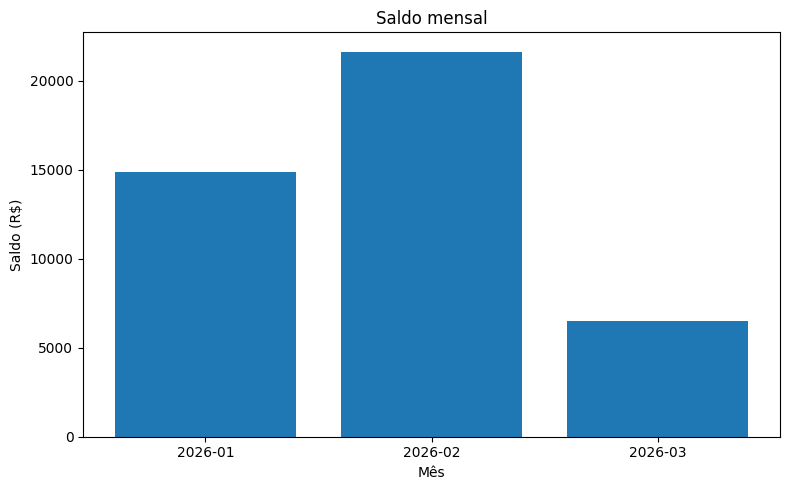

In [8]:
def main():
    df = ler_transacoes()

    if df is None:
        return

    df_valido, invalidas = validar_transacoes(df)

    resumo = gerar_relatorio(df_valido)

    suspeitas = listar_suspeitas(df_valido)

    exibir_relatorio(
        df,
        df_valido,
        resumo,
        suspeitas,
        invalidas
    )

    gerar_grafico(resumo)


if __name__ == "__main__":
    main()